<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/Efficientnet_hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

from sklearn.metrics import classification_report,confusion_matrix

In [2]:
dataset_path="/content/drive/MyDrive/DataSet/ArsenicSkinImageBD"

In [3]:
IMG_SIZE=224
BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator=val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8892 images belonging to 2 classes.
Found 8892 images belonging to 2 classes.


In [4]:
input_layer=Input(shape=(224,224,3))

x=Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x=BatchNormalization()(x)
x=Conv2D(32,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(64,(3,3),activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(64,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(128,(3,3),activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(128,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(256,(3,3),activation='relu')(x)
x=BatchNormalization()(x)
x=MaxPooling2D()(x)

cnn_features=GlobalAveragePooling2D()(x)
cnn_features=Dense(256,activation='relu')(cnn_features)

In [5]:
base_model=EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable=False

y=base_model.output

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
def se_block(input_tensor,ratio=8):

    filters=input_tensor.shape[-1]

    se=GlobalAveragePooling2D()(input_tensor)
    se=Dense(filters//ratio,activation='relu')(se)
    se=Dense(filters,activation='sigmoid')(se)

    se=Reshape((1,1,filters))(se)

    return Multiply()([input_tensor,se])

In [7]:
attention=se_block(y)
attention=GlobalAveragePooling2D()(attention)

In [8]:
y=GlobalAveragePooling2D()(y)

y=Dense(512,activation='relu')(y)
y=BatchNormalization()(y)

y=Dense(256,activation='relu')(y)
y=Dropout(0.5)(y)

efficient_features=Dense(256,activation='relu')(y)

In [9]:
combined=Concatenate()([cnn_features,efficient_features,attention])

z=Dense(512,activation='relu')(combined)
z=BatchNormalization()(z)

z=Dense(256,activation='relu')(z)
z=Dropout(0.5)(z)

z=Dense(128,activation='relu')(z)
z=Dropout(0.4)(z)

output=Dense(train_generator.num_classes,activation='softmax')(z)

model=Model(inputs=input_layer,outputs=output)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,592,417 (82.37 MB)

 Trainable params: 8,748,086 (33.37 MB)

 Non-trainable params: 12,844,331 (49.00 MB)

In [11]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [18]:
EPOCHS=10

history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.9036 - loss: 0.2322 - val_accuracy: 0.7804 - val_loss: 0.4135 - learning_rate: 0.0010
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.9148 - loss: 0.2095 - val_accuracy: 0.9410 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 265s 954ms/step - accuracy: 0.9245 - loss: 0.1964 - val_accuracy: 0.9177 - val_loss: 0.1964 - learning_rate: 0.0010
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 276s 992ms/step - accuracy: 0.9362 - loss: 0.1734 - val_accuracy: 0.8251 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 306s 933ms/step - accuracy: 0.9369 - loss: 0.1631 - val_accuracy: 0.5396 - val_loss: 2.5454 - learning_rate: 0.0010
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.9620 - loss: 0.1065 - val_accuracy: 0.9721 - val_loss: 0.0894 - learning_rate: 3.0000e-04
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.96

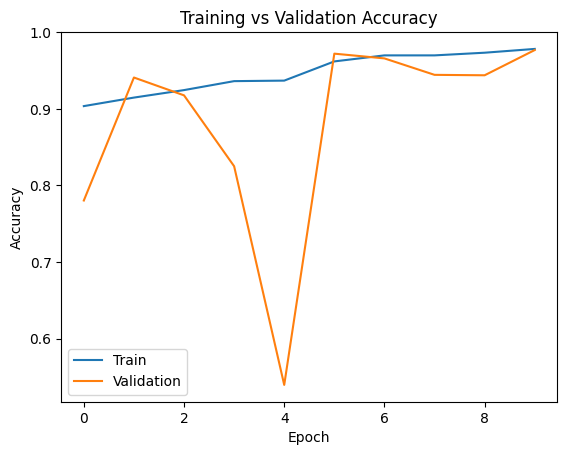

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

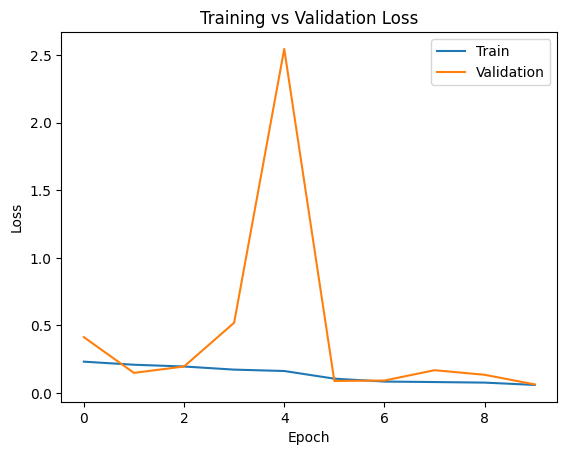

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])
plt.show()

In [21]:
loss,accuracy=model.evaluate(val_generator)

print("Test Accuracy:",accuracy)

278/278 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.9768 - loss: 0.0640
Test Accuracy: 0.9768331050872803


In [22]:
pred=model.predict(val_generator)

y_pred=np.argmax(pred,axis=1)
y_true=val_generator.classes

print(classification_report(y_true,y_pred))

278/278 ━━━━━━━━━━━━━━━━━━━━ 69s 247ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4446
           1       0.97      0.99      0.98      4446

    accuracy                           0.98      8892
   macro avg       0.98      0.98      0.98      8892
weighted avg       0.98      0.98      0.98      8892



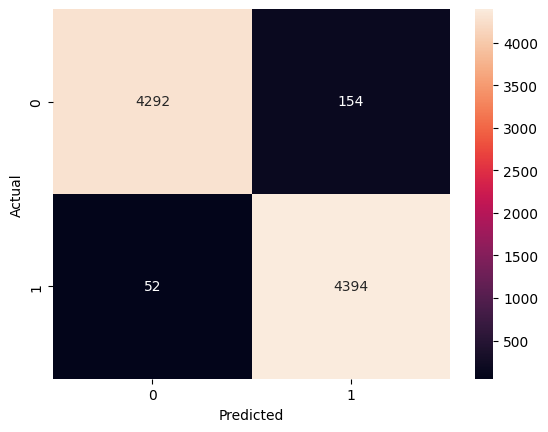

In [23]:
cm=confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()